Imports Libraries and Tools

In [15]:
# %pip install numpy
# %pip install pillow
#%pip install tensorflow
#%pip install scikit-learn

import os  # For directory and file operations
import numpy as np  # For numerical operations and handling image arrays
import random  # For generating random values for augmentation
import matplotlib.pyplot as plt

# keras
from PIL import Image, ImageEnhance  # For image processing and enhancement
from tensorflow.keras.preprocessing.image import load_img, img_to_array  # For loading images
from tensorflow.keras.models import Sequential  # For building the model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense  # For model layers
from tensorflow.keras.optimizers import Adam  # For optimizer
from tensorflow.keras.applications import VGG16  # For using VGG16 model
from sklearn.utils import shuffle  # For shuffling the data

Load Datasets

In [8]:
from pathlib import Path

# Base image directory
base_dir = Path.cwd() / "data-MRI-Images"

# Directories for training and testing data
train_dir = base_dir / "Training"
test_dir  = base_dir / "Testing"

# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

Data Visualization

In [ ]:
%pip install matplotlib

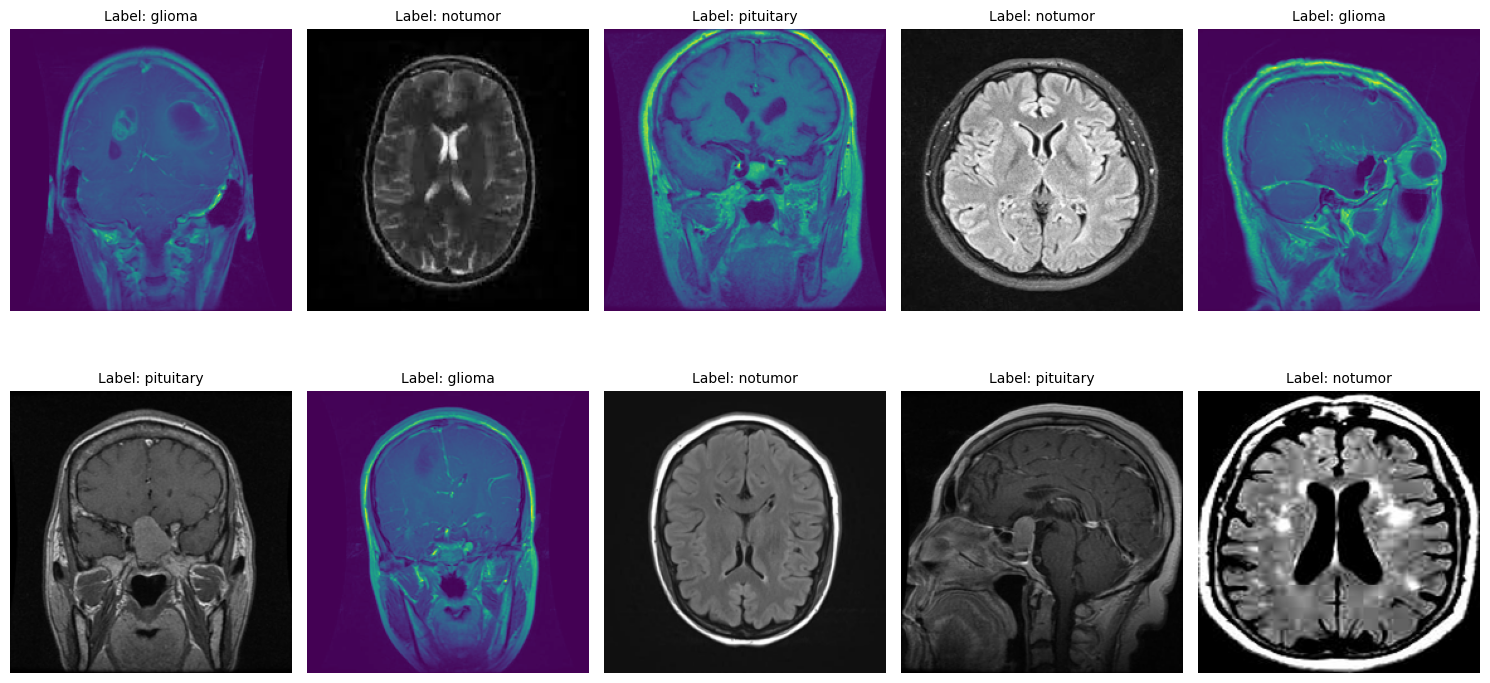

In [11]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    # Load image
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))  # Resize to consistent size

    # Display image
    axes[i].imshow(img)
    axes[i].axis('off')  # Hide axis
    # Display class label in the second row
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()

## Model

### Transfer Learning with VGG16

Used **VGG16** for transfer learning. The model is built on top of VGG16, which is a pre-trained convolutional neural network (CNN) for image classification.

---

### Model Architecture & Configuration

- **Loading VGG16:**
  The VGG16 model is loaded with `input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)`, `include_top=False`, `weights='imagenet'`.
  - The input shape is set to match the size of the images in the dataset, which is **128x128 pixels**.
  - The `include_top` parameter is set to `False`, which means that the final fully-connected layers of VGG16 that perform the classification will not be included.
  - The `weights` parameter is set to `'imagenet'` which means that the model will be pre-trained with a dataset of **1.4 million images** called ImageNet.

- **Freezing Base Layers:**
  The `for layer in base_model.layers:` loop is used to set all layers of the `base_model` (VGG16) to **non-trainable**, so that the weights of these layers will not be updated during training.

- **Unfreezing Last Three Layers:**
  The last three layers of the VGG16 model are set to trainable by using:
  - `base_model.layers[-2].trainable = True`
  - `base_model.layers[-3].trainable = True`
  - `base_model.layers[-4].trainable = True`

- **Building the Sequential Model:**
  A `Sequential` model is created and the VGG16 model is added to it with `model.add(base_model)`.

- **Flatten Layer:**
  A `Flatten` layer is added with `model.add(Flatten())`, which reshapes the output of the VGG16 model from a **3D tensor to a 1D tensor**, so that it can be processed by the next layers of the model.

- **First Dropout Layer:**
  A `Dropout` layer is added with `model.add(Dropout(0.3))`, which is used to **prevent overfitting** by randomly setting a fraction of input units to `0` at each update during training time.

- **Dense Hidden Layer:**
  A dense layer is added with **128 neurons** and `relu` activation function using `model.add(Dense(128, activation='relu'))`.

- **Second Dropout Layer:**
  Another `Dropout` layer is added with `model.add(Dropout(0.2))`.

- **Output Dense Layer:**
  The output dense layer is added with the number of neurons equal to the **number of unique labels** and `softmax` activation function using `model.add(Dense(len(unique_labels), activation='softmax'))`.
  - The `softmax` activation function is used to give a **probability distribution** over the possible classes.

---

In [ ]:
%pip install "tensorflow[and-cuda]"

In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

2026-03-02 14:27:11.574457: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 14:27:11.614659: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-02 14:27:12.750229: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# DATA GENERATOR
# Creates batches of images + labels from file paths.

print(len(train_paths), len(train_labels))

# Create label map once (not every batch)
unique_labels = sorted(set(train_labels))
labels_map = {name: i for i, name in enumerate(unique_labels)}

def datagen(paths, labels, batch_size=20):
    while True:
        # Shuffle each epoch
        paths, labels = shuffle(paths, labels)

        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_labels = labels[i:i + batch_size]

            imgs = []
            labs = []

            for p, l in zip(batch_paths, batch_labels):
                img = load_img(p, target_size=(IMAGE_SIZE, IMAGE_SIZE))
                img = img_to_array(img) / 255.0
                imgs.append(img)
                labs.append(labels_map[l])

            yield np.array(imgs), np.array(labs)


# MODEL ARCHITECTURE
IMAGE_SIZE = 128

base_model = VGG16(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze last 3 layers
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True


# FINAL MODEL
model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    base_model,
    Flatten(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(len(unique_labels), activation='softmax')   # FIXED
])


# COMPILE
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)


# TRAINING
batch_size = 20
steps = len(train_paths) // batch_size
epochs = 5

history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size),
    epochs=epochs,
    steps_per_epoch=steps
)

5600 5600


I0000 00:00:1772442231.758113   70946 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2143 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/5


2026-03-02 14:33:54.335497: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ee66000f530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-02 14:33:54.335513: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2026-03-02 14:33:54.396917: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-02 14:33:54.885433: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-03-02 14:33:55.803984: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1329', 52 bytes spill stores, 52 bytes spill loads

2026-03-02 14:33:55.946812: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas 

  1/280 ━━━━━━━━━━━━━━━━━━━━ 50:36 11s/step - loss: 1.8466 - sparse_categorical_accuracy: 0.0500

I0000 00:00:1772442243.795546   73505 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


280/280 ━━━━━━━━━━━━━━━━━━━━ 42s 112ms/step - loss: 0.4755 - sparse_categorical_accuracy: 0.8095
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 32s 113ms/step - loss: 0.2325 - sparse_categorical_accuracy: 0.9139
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 32s 116ms/step - loss: 0.1682 - sparse_categorical_accuracy: 0.9355
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 33s 117ms/step - loss: 0.1044 - sparse_categorical_accuracy: 0.9611
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 32s 115ms/step - loss: 0.0750 - sparse_categorical_accuracy: 0.9739


Train and Val Plots

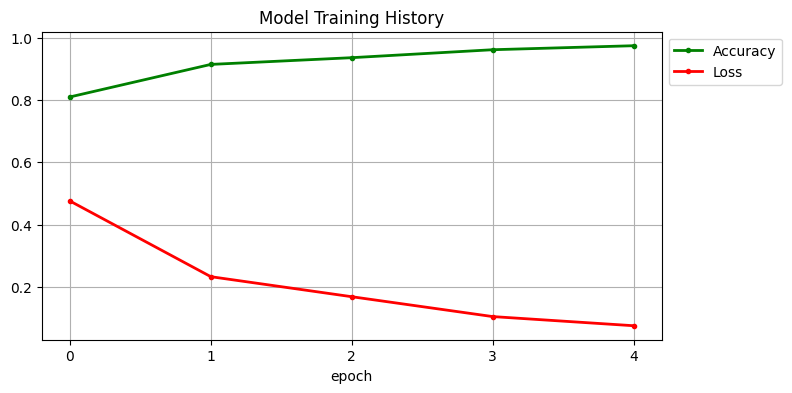

In [16]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()


Model Classification Report

In [ ]:
%pip install seaborn

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

def open_images(paths):
    imgs = []
    for p in paths:
        img = load_img(p, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        img = img_to_array(img) / 255.0
        imgs.append(img)
    return np.array(imgs)


def encode_label(labels):
    unique_labels = sorted(set(train_labels))   # same mapping as training
    label_map = {name:i for i, name in enumerate(unique_labels)}
    return np.array([label_map[l] for l in labels])

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

2026-03-02 14:43:42.847586: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_188', 60 bytes spill stores, 60 bytes spill loads

2026-03-02 14:43:44.544456: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.04GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-03-02 14:43:46.573743: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.55GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-03-02 14:43:47.202194: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory tr

50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 107ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.78      0.85       400
           1       0.84      0.93      0.88       400
           2       0.92      1.00      0.95       400
           3       0.99      0.97      0.98       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



Model Confusion Plot

Confusion Matrix:
[[311  60  29   0]
 [ 19 373   6   2]
 [  1   0 399   0]
 [  0  10   2 388]]


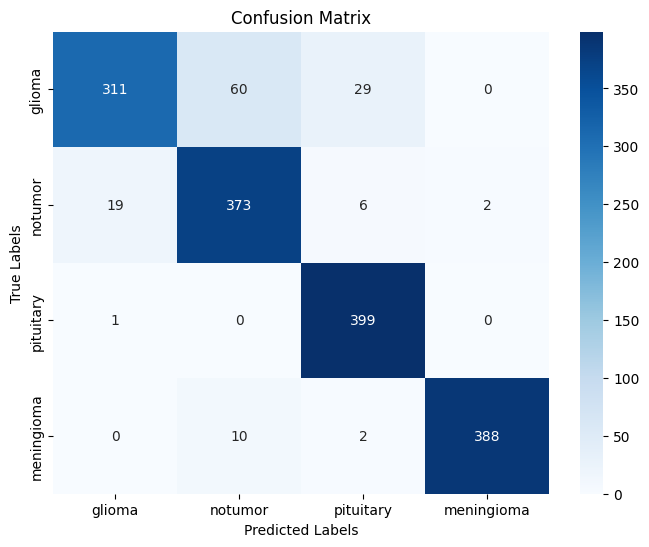

In [21]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


Roc Curve Plot

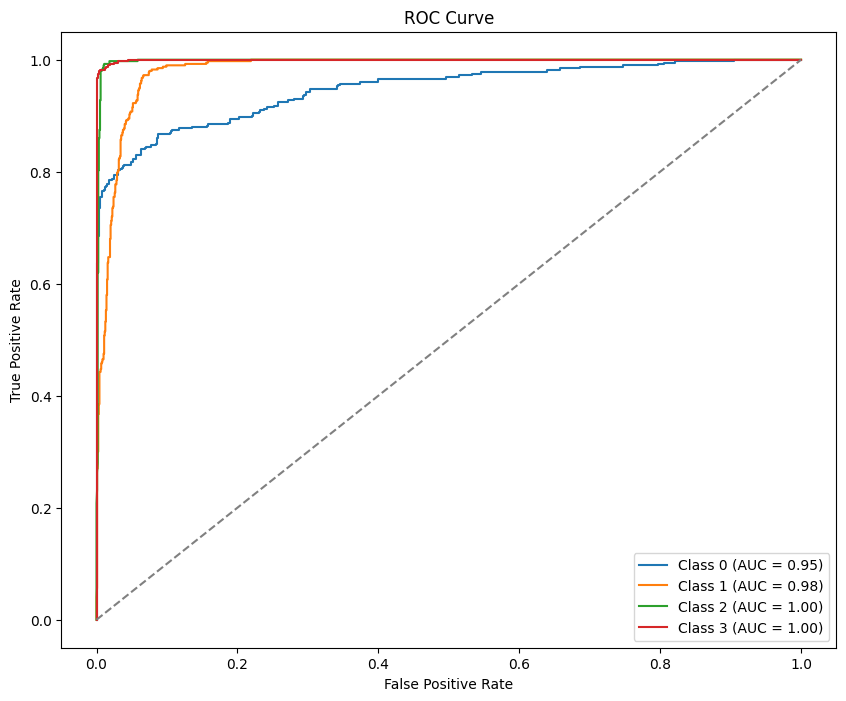

In [22]:
# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

Save Model

In [24]:
from tensorflow.keras.callbacks import ModelCheckpoint

ckpt = ModelCheckpoint(
    "best_model.keras",
    monitor="loss",
    save_best_only=True
)

history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size),
    epochs=epochs,
    steps_per_epoch=steps,
    callbacks=[ckpt]
)

Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 33s 116ms/step - loss: 0.0546 - sparse_categorical_accuracy: 0.9793
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 32s 115ms/step - loss: 0.0473 - sparse_categorical_accuracy: 0.9816
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 31s 112ms/step - loss: 0.0582 - sparse_categorical_accuracy: 0.9786
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 38s 135ms/step - loss: 0.0346 - sparse_categorical_accuracy: 0.9891
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 33s 118ms/step - loss: 0.0215 - sparse_categorical_accuracy: 0.9930


Load Model

In [25]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('best_model.keras')

MRI Tumor Detection System

In [ ]:
# MRI Tumor Detection Function

# IMPORTANT:
# Class label order MUST be same as training.

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array


# Load labels saved during training
np.save("labels.npy", unique_labels)

class_labels = np.load("labels.npy", allow_pickle=True)


def detect_and_display(img_path, model, image_size=128):
    """
    Load image -> preprocess -> predict -> show result.

    If class is 'notumor' -> show "No Tumor"
    Else -> show tumor type + confidence
    """

    try:
        # 1. Load and preprocess image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0      # Normalize [0,1]
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # 2. Model prediction
        preds = model.predict(img_array, verbose=0)

        predicted_index = np.argmax(preds)
        confidence = preds[0][predicted_index]
        label = class_labels[predicted_index]

        # 3. Result text
        if label == "notumor":
            result = "No Tumor"
        else:
            result = f"Tumor: {label}"

        # 4. Show image + prediction
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{result} (Confidence: {confidence*100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing image:", e)

### Testing

meningioma


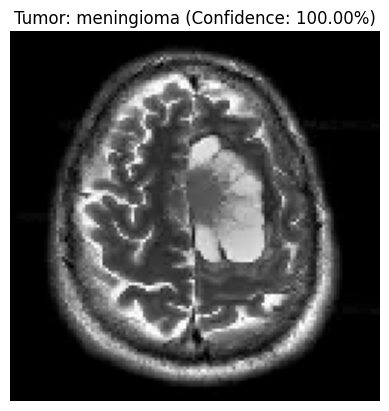

In [ ]:
# Example usage 1, checking the tumor detection
base_dir = Path.cwd() / "data-MRI-Images"

# Correct image path
image_path = base_dir / "Testing" / "meningioma" / "Te-me_290.jpg"

# Run detection
detect_and_display(image_path, model)

no-tumor

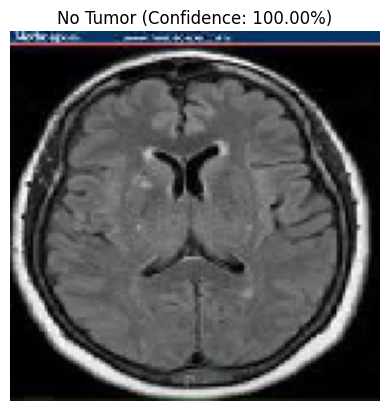

In [31]:
# Example usage 2, checking the no-tumor detection
base_dir = Path.cwd() / "data-MRI-Images"

# Correct image path
image_path = base_dir / "Testing" / "notumor" / "Te-no_63.jpg"

# Run detection
detect_and_display(image_path, model)

glioma

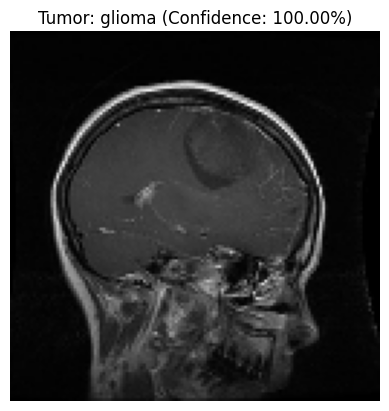

In [32]:
# Example usage 1, checking the tumor detection
base_dir = Path.cwd() / "data-MRI-Images"

# Correct image path
image_path = base_dir / "Testing" / "glioma" / "Te-gl_17.jpg"

# Run detection
detect_and_display(image_path, model)

pituitary

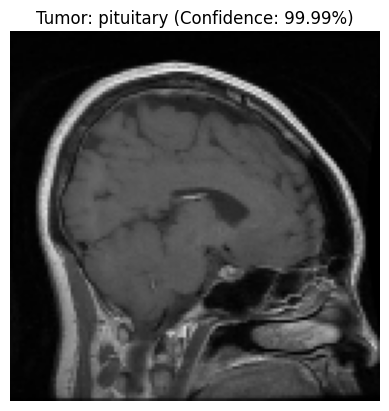

In [33]:
# Example usage 1, checking the tumor detection
base_dir = Path.cwd() / "data-MRI-Images"

# Correct image path
image_path = base_dir / "Testing" / "pituitary" / "Te-pi_52.jpg"

# Run detection
detect_and_display(image_path, model)